In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('student_placement_synthetic.csv')

# **EDA**

In [ ]:
df

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,3,2,0,0,3,0,NaN
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,2,3,0,1,0,1,16.58
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,2,1,0,1,2,1,17.24
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,4,2,0,0,1,1,17.01


In [ ]:
df.isnull().sum()

,0
branch,0
college_tier,0
cgpa,0
backlogs,0
coding_skills,0
dsa_score,0
aptitude_score,0
communication_skills,0
ml_knowledge,0
system_design,0


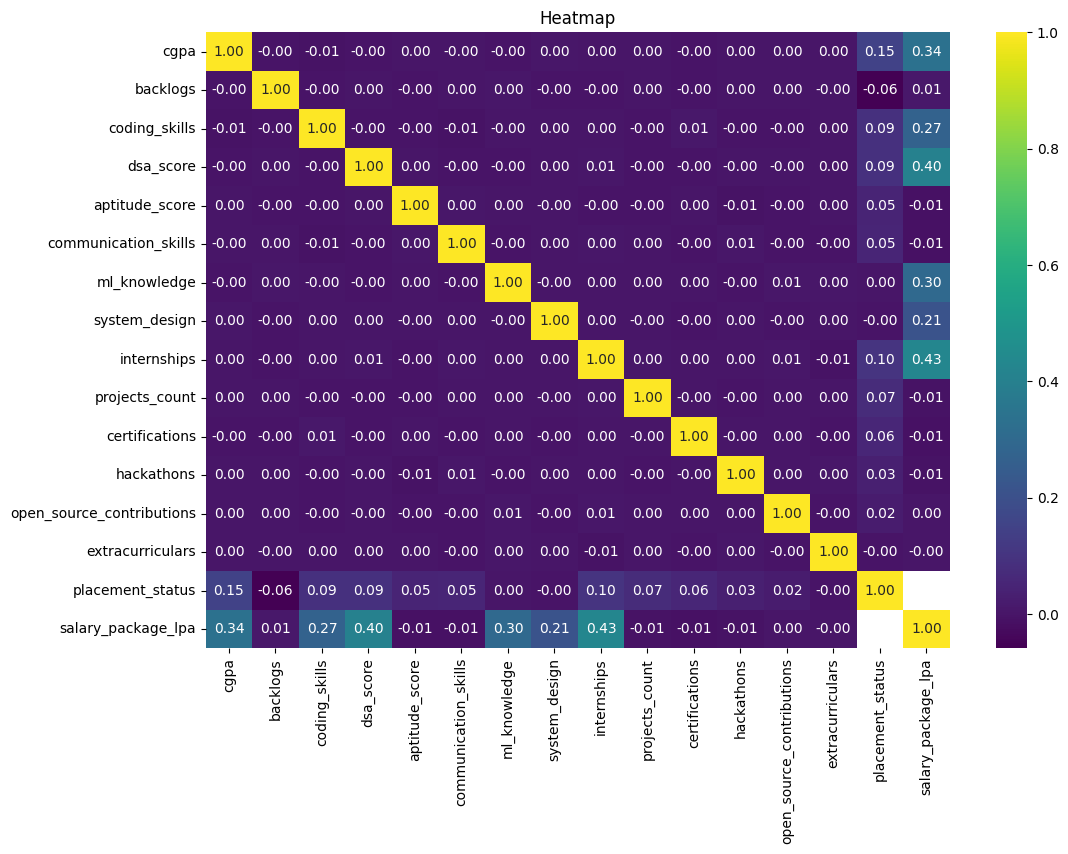

In [ ]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='viridis', fmt=".2f")
plt.title("Heatmap")
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100

In [ ]:
df['branch'].unique()

array(['ECE', 'Chemical', 'EE', 'CE', 'CSE', 'IT', 'ME'], dtype=object)

In [ ]:
df['college_tier'].unique()

array(['Tier-3', 'Tier-2', 'Tier-1'], dtype=object)

In [ ]:
df['placement_status'].value_counts()

,count
placement_status,
1,68475
0,31525


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cgpa,100000.0,7.206381,0.925235,4.00,6.58,7.21,7.83,10.00
backlogs,100000.0,0.547010,0.862727,0.00,0.00,0.00,1.00,3.00
coding_skills,100000.0,5.995147,1.496302,1.00,5.00,6.00,7.00,10.00
dsa_score,100000.0,5.500711,1.781961,1.00,4.30,5.50,6.70,10.00
aptitude_score,100000.0,64.990511,11.990892,20.00,56.80,65.00,73.10,100.00
communication_skills,100000.0,5.990614,1.496552,1.00,5.00,6.00,7.00,10.00
ml_knowledge,100000.0,4.508752,1.968278,0.00,3.20,4.50,5.90,10.00
system_design,100000.0,4.008210,1.778405,0.00,2.80,4.00,5.20,10.00
internships,100000.0,1.095040,0.940264,0.00,0.00,1.00,2.00,3.00
projects_count,100000.0,2.397280,1.242829,0.00,1.00,2.00,3.00,5.00


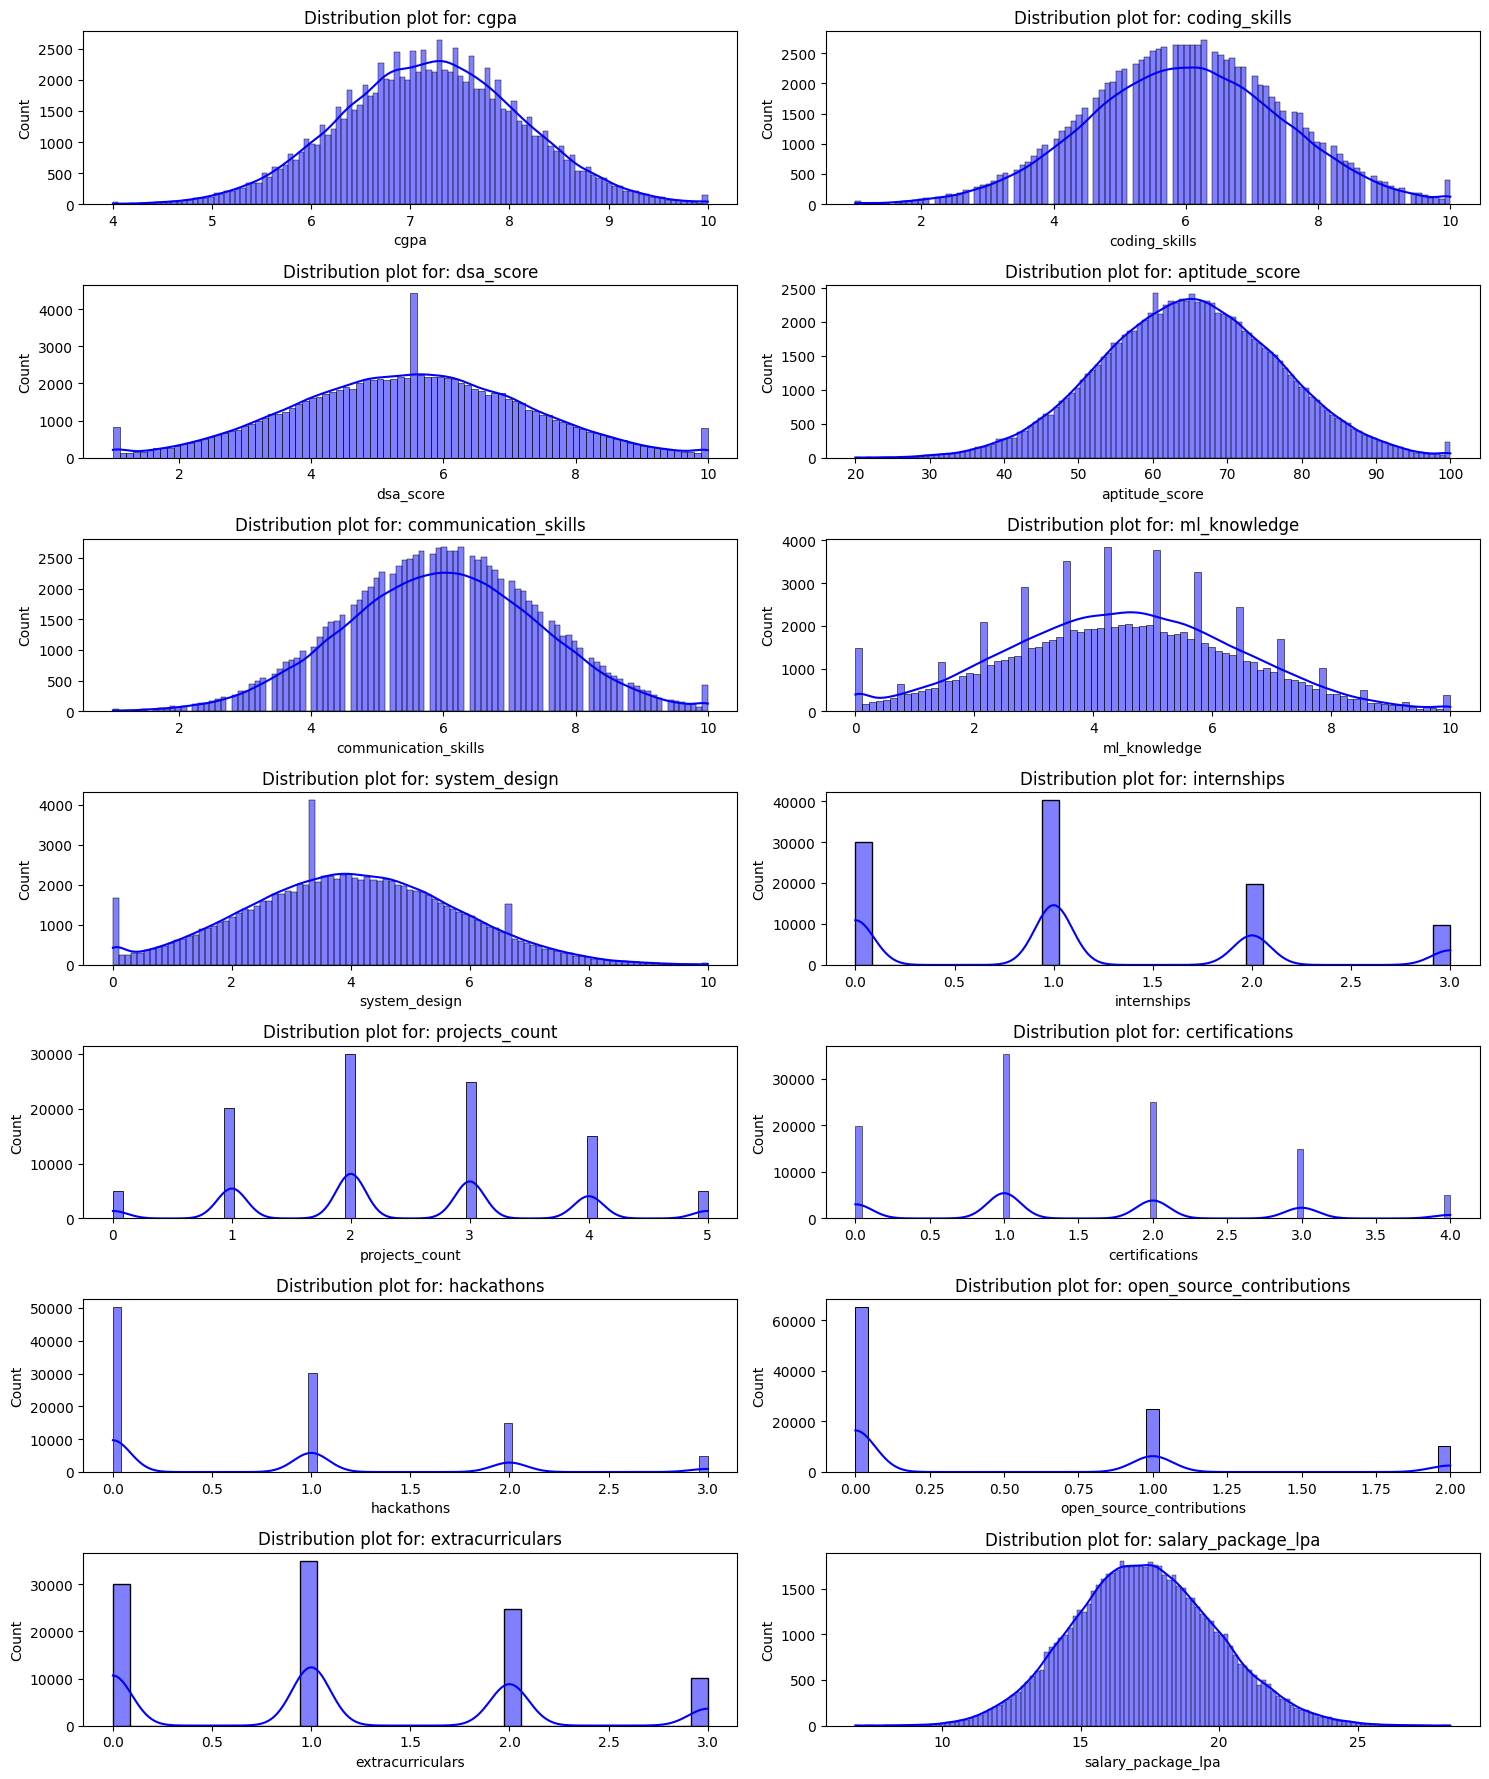

In [ ]:
numeric_cols = df.drop(['placement_status','college_tier','backlogs'], axis=1).select_dtypes(include='number').columns

plt.figure(figsize=(15, 20))

for i, c in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols) // 2 + 1, 2, i)
    sns.histplot(df[c], kde=True, color='blue')
    plt.title('Distribution plot for: ' + c)

plt.tight_layout()
plt.show()

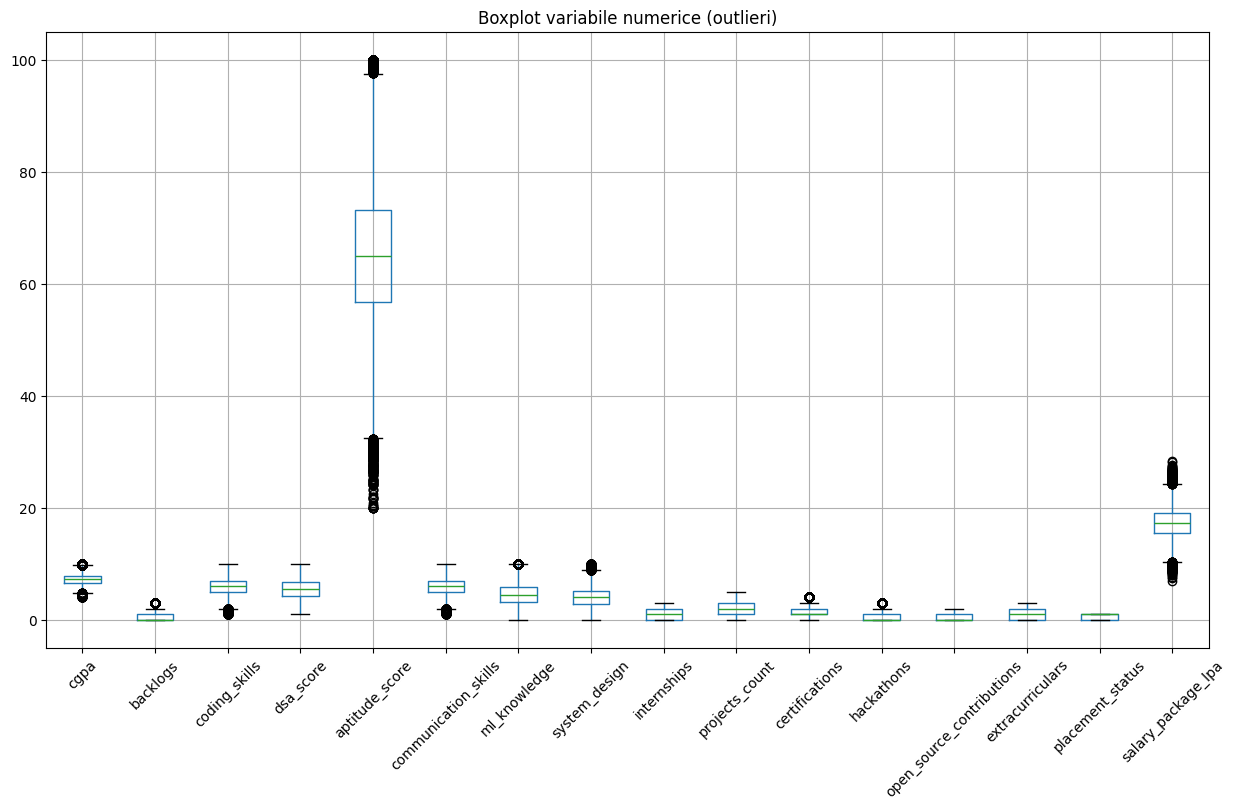

In [ ]:
plt.figure(figsize=(15, 8))
df.select_dtypes(include=['int64','float64']).boxplot()
plt.title("Boxplot variabile numerice (outlieri)")
plt.xticks(rotation=45)
plt.show()

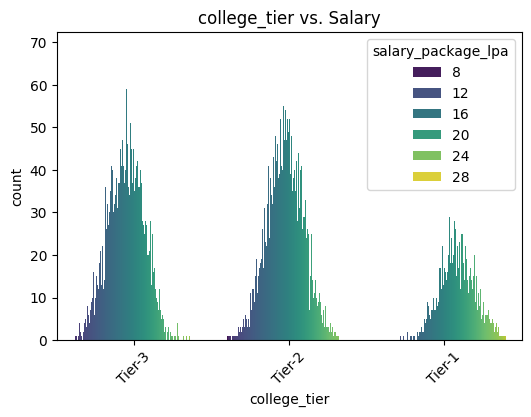

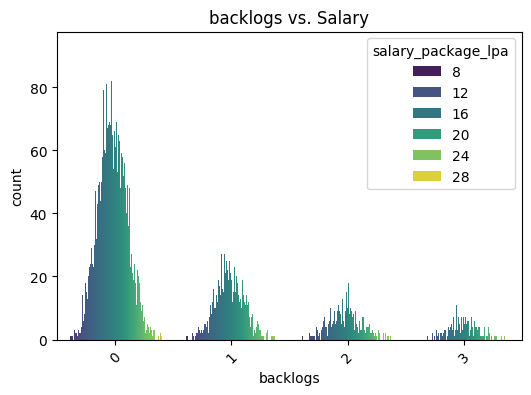

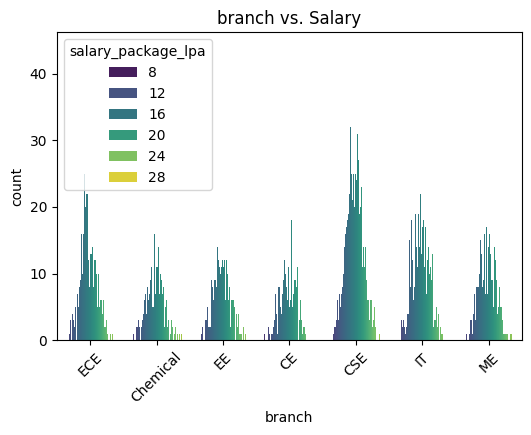

In [ ]:
categorical_cols = ['college_tier','backlogs','branch']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='salary_package_lpa', palette='viridis')
    plt.title(f"{col} vs. Salary")
    plt.xticks(rotation=45)
    plt.show()

/tmp/ipykernel_21187/3403072184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='placement_status', y=col, palette='coolwarm')


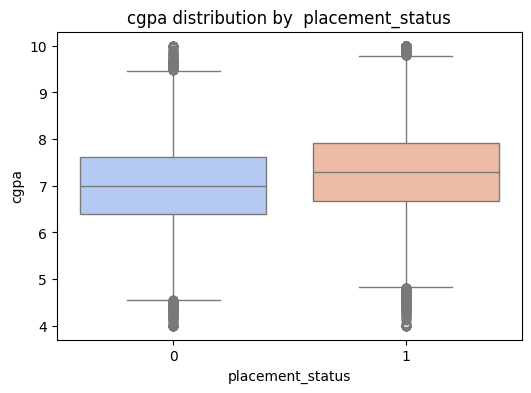

/tmp/ipykernel_21187/3403072184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='placement_status', y=col, palette='coolwarm')


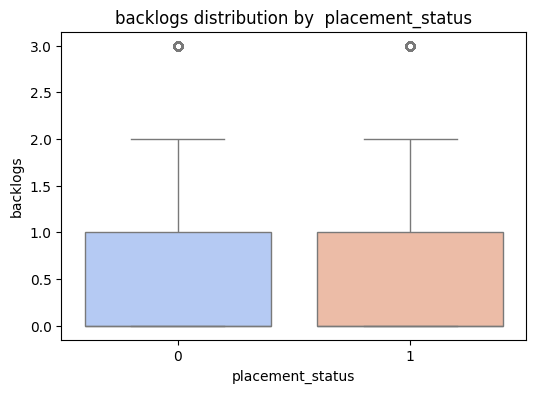

/tmp/ipykernel_21187/3403072184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='placement_status', y=col, palette='coolwarm')


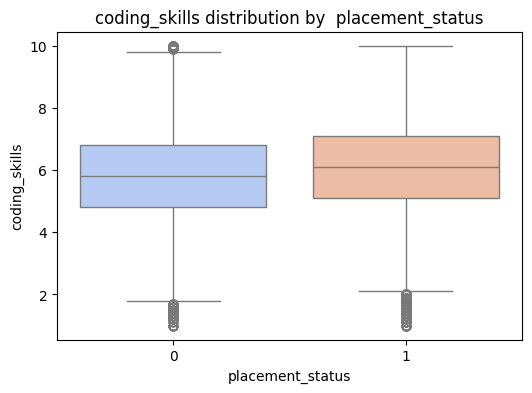

/tmp/ipykernel_21187/3403072184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='placement_status', y=col, palette='coolwarm')


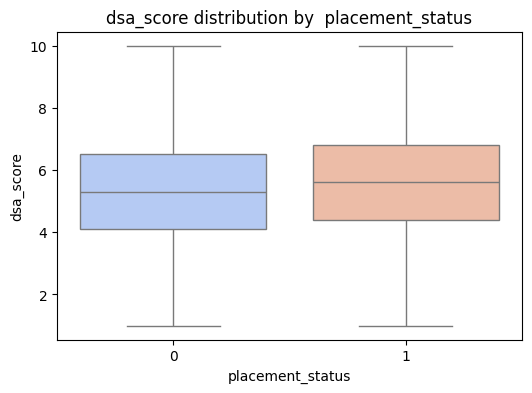

/tmp/ipykernel_21187/3403072184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='placement_status', y=col, palette='coolwarm')


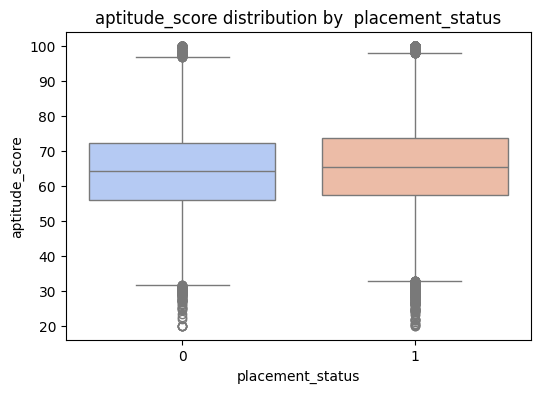

/tmp/ipykernel_21187/3403072184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='placement_status', y=col, palette='coolwarm')


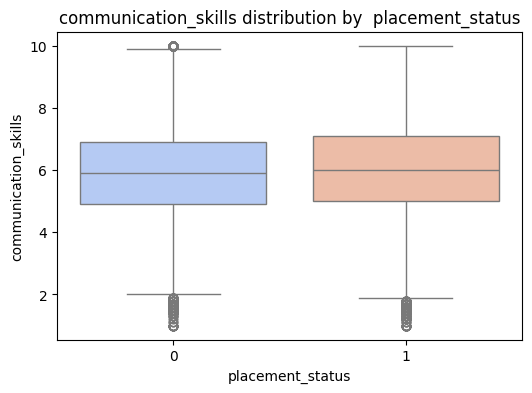

/tmp/ipykernel_21187/3403072184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='placement_status', y=col, palette='coolwarm')


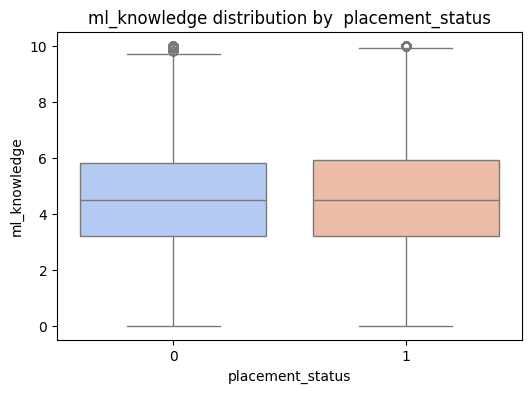

/tmp/ipykernel_21187/3403072184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='placement_status', y=col, palette='coolwarm')


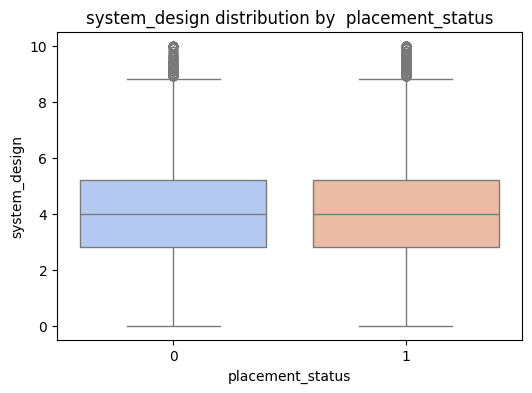

/tmp/ipykernel_21187/3403072184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='placement_status', y=col, palette='coolwarm')


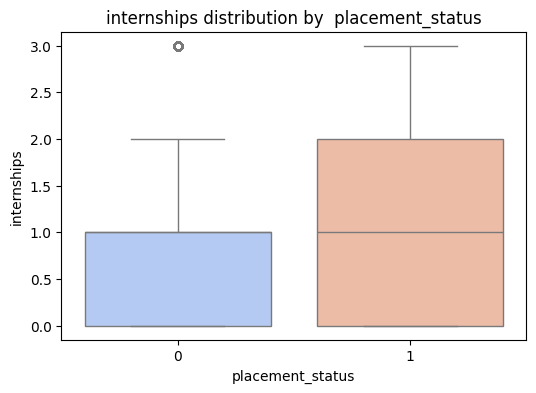

/tmp/ipykernel_21187/3403072184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='placement_status', y=col, palette='coolwarm')


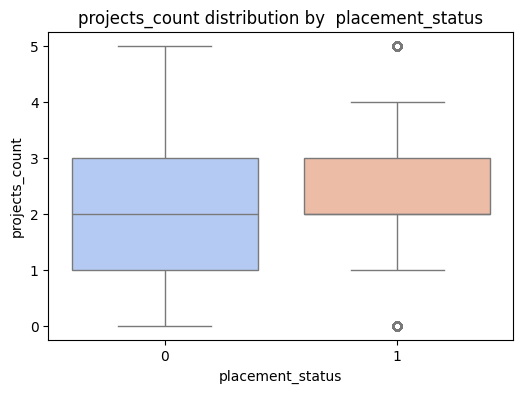

/tmp/ipykernel_21187/3403072184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='placement_status', y=col, palette='coolwarm')


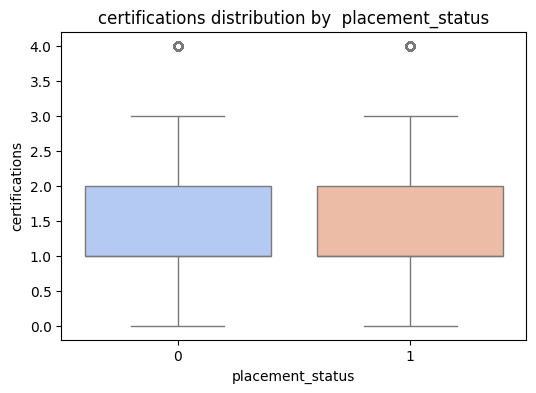

/tmp/ipykernel_21187/3403072184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='placement_status', y=col, palette='coolwarm')


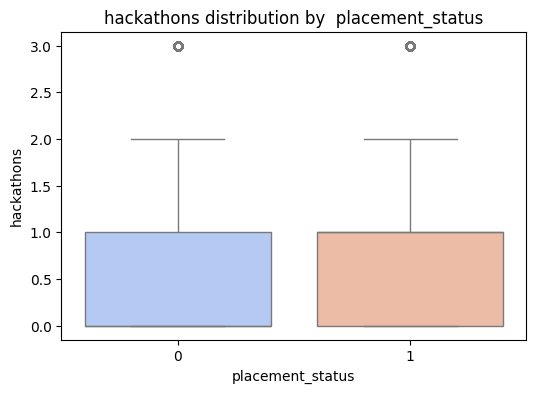

/tmp/ipykernel_21187/3403072184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='placement_status', y=col, palette='coolwarm')


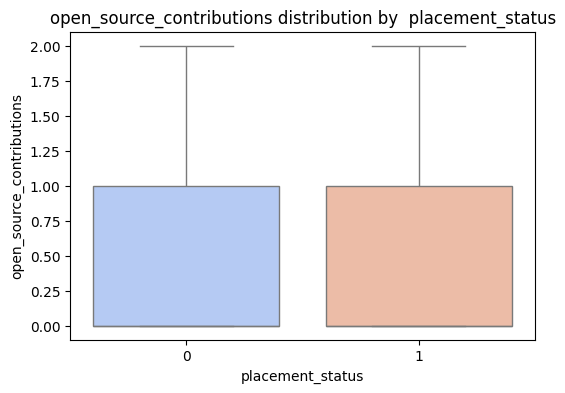

/tmp/ipykernel_21187/3403072184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='placement_status', y=col, palette='coolwarm')


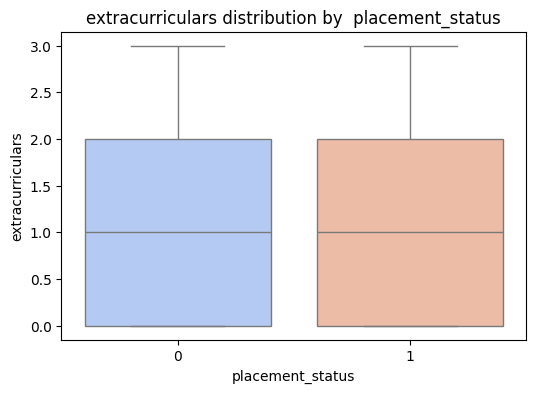

In [ ]:
numeric_cols = df.drop(['placement_status','salary_package_lpa'], axis=1).select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='placement_status', y=col, palette='coolwarm')
    plt.title(f"{col} distribution by  placement_status")
    plt.show()

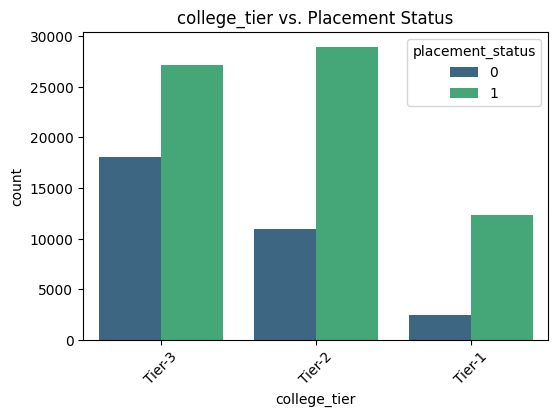

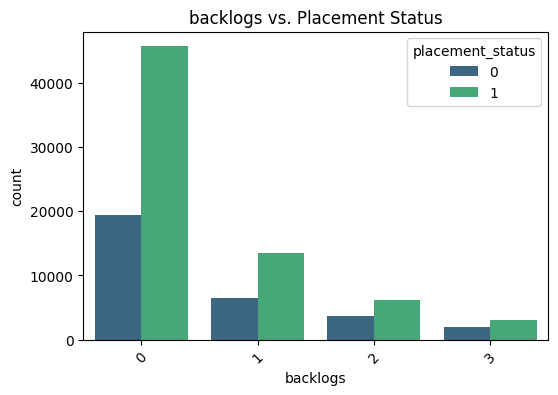

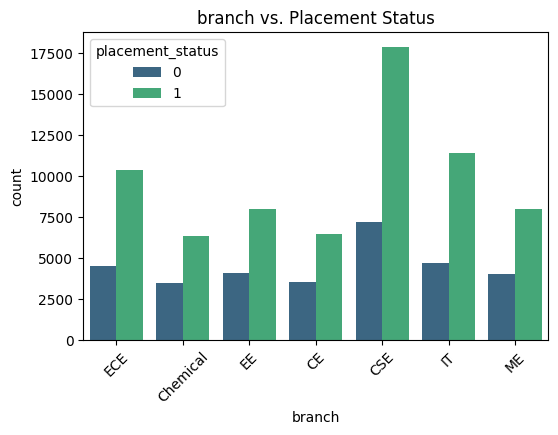

In [ ]:
categorical_cols = ['college_tier','backlogs','branch']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='placement_status', palette='viridis')
    plt.title(f"{col} vs. Placement Status")
    plt.xticks(rotation=45)
    plt.show()

# Preprocesare

In [ ]:
df_prepoces=df.copy()

In [ ]:
df_prepoces.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [ ]:
df_prepoces.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100

In [ ]:
df_prepoces['branch'].unique()

array(['ECE', 'Chemical', 'EE', 'CE', 'CSE', 'IT', 'ME'], dtype=object)

In [ ]:
df_prepoces['college_tier'].unique()

array(['Tier-3', 'Tier-2', 'Tier-1'], dtype=object)

In [ ]:
df_prepoces['college_tier']=df_prepoces['college_tier'].map({'Tier-1':1,'Tier-2':2,'Tier-3':3})

In [ ]:
df_prepoces=pd.get_dummies(df_prepoces,columns=['branch'],drop_first=True)

In [ ]:
df_prepoces.drop(columns=['placement_status'],inplace=True)

In [ ]:
df_train=df_prepoces.dropna(subset=['salary_package_lpa'])

In [ ]:
df_train.head()

,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,...,hackathons,open_source_contributions,extracurriculars,salary_package_lpa,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME
0,3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,...,3,2,1,14.75,False,False,True,False,False,False
2,2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,...,1,2,0,19.06,False,False,False,True,False,False
4,2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,...,3,0,1,13.42,True,False,False,False,False,False
5,3,6.21,1,6.7,6.5,69.9,5.0,4.0,5.2,2,...,2,0,1,16.47,True,False,False,False,False,False
6,3,7.91,0,7.0,3.9,61.5,6.7,4.9,2.2,2,...,1,0,3,16.51,True,False,False,False,False,False


In [ ]:
df_train.isnull().sum()

,0
college_tier,0
cgpa,0
backlogs,0
coding_skills,0
dsa_score,0
aptitude_score,0
communication_skills,0
ml_knowledge,0
system_design,0
internships,0


In [ ]:
df_predict=df_prepoces[df_prepoces['salary_package_lpa'].isnull()]

In [ ]:
df_predict.isnull().sum()

,0
college_tier,0
cgpa,0
backlogs,0
coding_skills,0
dsa_score,0
aptitude_score,0
communication_skills,0
ml_knowledge,0
system_design,0
internships,0


In [ ]:
X=df_train.drop(columns=['salary_package_lpa'])
Y=df_train['salary_package_lpa']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score,mean_absolute_percentage_error

def metrics(y_test, y_pred):
  mse = mean_squared_error(y_test, y_pred)
  rmse = root_mean_squared_error(y_test, y_pred)
  mae = mean_absolute_error(y_test, y_pred)
  r2=r2_score(y_test, y_pred)
  mape=mean_absolute_percentage_error(y_test, y_pred)

  print('MSE: ', mse)
  print('RMSE: ', rmse)
  print('MAE: ', mae)
  print('R2: ', r2)
  print('MAPE: ', mape)

In [ ]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import lightgbm as lgb
from xgboost import XGBRegressor

from sklearn.neural_network import MLPRegressor

from tqdm import tqdm

In [ ]:
rf = RandomForestRegressor()
et = ExtraTreesRegressor()
ada = AdaBoostRegressor()
gbr = GradientBoostingRegressor()
lr = LinearRegression()
svr = SVR()
knn = KNeighborsRegressor()
dt = DecisionTreeRegressor()
lgbm = lgb.LGBMRegressor()
xgb = XGBRegressor()

lista_regressor = [rf, et, ada, gbr, lr, dt, lgbm, xgb]

In [ ]:
def train_model(lista,X_train,X_test,y_train,y_test):
  ct=0
  for i in lista:
    print(str(i).split('(')[0])
    i.fit(X_train,y_train)
    y_pred=i.predict(X_test)
    print(metrics(y_test,y_pred))
    print('---------------------------------------------')
    if(r2_score(y_test,y_pred)>ct):
      ct=r2_score(y_test,y_pred)
      ct2=mean_absolute_percentage_error(y_test,y_pred)
      best_model=str(i).split('(')[0]
  print(f'The best model was: {best_model} with an R2 score of {ct} and a MAPE of {ct2}')

In [ ]:
train_model(lista_regressor,X_train,X_test,y_train,y_test)

RandomForestRegressor
MSE:  1.6130023532048194
RMSE:  1.2700402958980552
MAE:  1.0110897261774372
R2:  0.7605367838742707
MAPE:  0.06003557011338227
None
---------------------------------------------
ExtraTreesRegressor
MSE:  1.6082309422051841
RMSE:  1.268160456016976
MAE:  1.0094438700255568
R2:  0.7612451383420494
MAPE:  0.05996207430525775
None
---------------------------------------------
AdaBoostRegressor
MSE:  1.898124925042313
RMSE:  1.3777245461420482
MAE:  1.0958445943348323
R2:  0.7182080371699714
MAPE:  0.06524888426979264
None
---------------------------------------------
GradientBoostingRegressor
MSE:  1.4831500118264866
RMSE:  1.2178464648002583
MAE:  0.9703794783244961
R2:  0.779814411849289
MAPE:  0.0577645342806557
None
---------------------------------------------
LinearRegression
MSE:  1.5261749914284188
RMSE:  1.2353845520437832
MAE:  0.9868987287847273
R2:  0.7734270064194382
MAPE:  0.058538023542488486
None
---------------------------------------------
DecisionTr

In [ ]:
df_predict.drop(columns=['salary_package_lpa'],inplace=True)

/tmp/ipykernel_21187/4159925119.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predict.drop(columns=['salary_package_lpa'],inplace=True)


In [ ]:
y_pred=lgbm.predict(df_predict)

In [ ]:
df_predict['salary_package_lpa']=y_pred

/tmp/ipykernel_21187/1277405919.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predict['salary_package_lpa']=y_pred


In [ ]:
y_pred.mean()

np.float64(16.216413775862225)

In [ ]:
np.median(y_pred)

np.float64(16.1305067953501)

In [ ]:
df_predict.head()

,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,...,hackathons,open_source_contributions,extracurriculars,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME,salary_package_lpa
1,2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,...,0,0,0,False,True,False,False,False,False,15.966267
3,2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,...,0,0,0,False,False,False,False,False,False,13.944307
7,3,6.95,0,6.1,6.0,44.4,5.5,4.5,6.3,1,...,1,1,0,False,False,False,False,True,False,17.327750
15,3,7.37,2,4.3,7.7,82.4,8.8,6.6,4.7,2,...,0,1,1,True,False,False,False,False,False,19.243949
17,2,6.24,0,4.3,3.6,60.6,5.6,4.9,7.0,1,...,0,0,1,False,False,False,False,False,False,15.166372


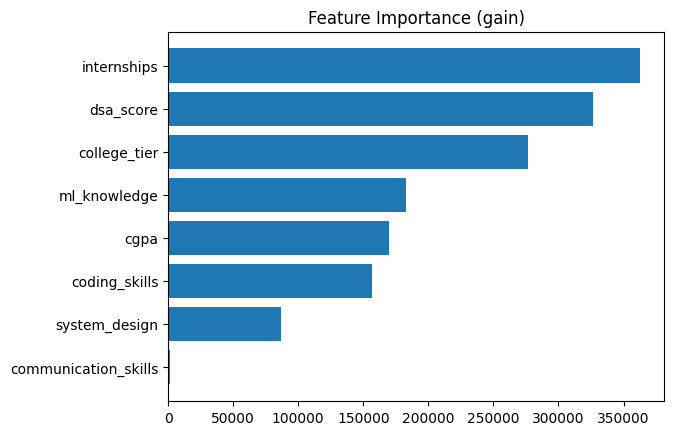

In [ ]:
importance = lgbm.booster_.feature_importance(importance_type='gain')
feature_names = lgbm.booster_.feature_name()

df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

plt.figure()
plt.barh(df['feature'][:8], df['importance'][:8])
plt.gca().invert_yaxis()
plt.title("Feature Importance (gain)")
plt.show()

In [ ]:
from sklearn.metrics import r2_score

base_model = lgb.LGBMRegressor()
base_model.fit(X_train, y_train)

base_pred = base_model.predict(X_test)
base_score = r2_score(y_test, base_pred)

print("Baseline:", base_score)

for col in X.columns:
    X_train_drop = X_train.drop(columns=[col])
    X_test_drop = X_test.drop(columns=[col])

    model = lgb.LGBMRegressor()
    model.fit(X_train_drop, y_train)

    y_pred = model.predict(X_test_drop)
    score = r2_score(y_test, y_pred)

    print(f"{col} -> impact: {base_score - score}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005894 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1032
[LightGBM] [Info] Number of data points in the train set: 54780, number of used features: 21
[LightGBM] [Info] Start training from score 17.301476
Baseline: 0.7838902665880153
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010660 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1028
[LightGBM] [Info] Number of data points in the train set: 54780, number of used features: 20
[LightGBM] [Info] Start training from score 17.301476
college_tier -> impact: 0.10574593300745105
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020081 seconds.
You can s

In [ ]:
df_train.head()

,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,...,hackathons,open_source_contributions,extracurriculars,salary_package_lpa,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME
0,3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,...,3,2,1,14.75,False,False,True,False,False,False
2,2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,...,1,2,0,19.06,False,False,False,True,False,False
4,2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,...,3,0,1,13.42,True,False,False,False,False,False
5,3,6.21,1,6.7,6.5,69.9,5.0,4.0,5.2,2,...,2,0,1,16.47,True,False,False,False,False,False
6,3,7.91,0,7.0,3.9,61.5,6.7,4.9,2.2,2,...,1,0,3,16.51,True,False,False,False,False,False


In [ ]:
importance = lgbm.booster_.feature_importance(importance_type='gain')
feature_names = lgbm.booster_.feature_name()

In [ ]:
df_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(df_imp.head(20))

                      feature     importance
9                 internships  363001.732200
4                   dsa_score  326241.831464
0                college_tier  276322.910282
7                ml_knowledge  183032.081513
1                        cgpa  170069.909721
3               coding_skills  156350.155676
8               system_design   86982.484019
6        communication_skills    1119.281005
5              aptitude_score    1107.570868
10             projects_count     388.024021
11             certifications     304.353017
12                 hackathons     230.743809
13  open_source_contributions     222.361332
14           extracurriculars     174.863029
2                    backlogs     151.953730
17                 branch_ECE     113.883100
15                 branch_CSE     105.992151
18                  branch_EE      57.244310
16            branch_Chemical      50.653669
20                  branch_ME      45.594010


In [ ]:
top_features = df_imp['feature'].head(7).to_list()

In [ ]:
top_features

['internships',
 'dsa_score',
 'college_tier',
 'ml_knowledge',
 'cgpa',
 'coding_skills',
 'system_design']

In [ ]:
df_prepoces2 = df_prepoces[top_features + ['salary_package_lpa']]

In [ ]:
df_prepoces2.head()

,internships,dsa_score,college_tier,ml_knowledge,cgpa,coding_skills,system_design,salary_package_lpa
0,1,4.4,3,6.4,6.70,7.6,0.3,14.75
1,0,7.9,2,6.3,5.70,5.4,1.9,NaN
2,1,6.8,2,4.4,7.19,5.6,5.2,19.06
3,1,3.1,2,1.1,6.48,5.2,6.7,NaN
4,1,4.7,2,2.7,6.71,5.9,2.8,13.42


In [ ]:
df_train2=df_prepoces2.dropna(subset=['salary_package_lpa'])

In [ ]:
X2=df_train2.drop(columns=['salary_package_lpa'])
Y2=df_train2['salary_package_lpa']

In [ ]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, Y2, test_size=0.2, random_state=42)

In [ ]:
lgbm2 = lgb.LGBMRegressor()

In [ ]:
lgbm2.fit(X_train2,y_train2)
y_pred=lgbm2.predict(X_test2)
print(metrics(y_test2,y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001356 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 648
[LightGBM] [Info] Number of data points in the train set: 54780, number of used features: 7
[LightGBM] [Info] Start training from score 17.301476
MSE:  1.4518935549323029
RMSE:  1.2049454572437306
MAE:  0.9595243047698729
R2:  0.7844546851121924
MAPE:  0.056913822080098916
None


In [ ]:
# input de la utilizator
internships = float(input("internships = "))
dsa_score = float(input("dsa_score = "))
college_tier = int(input("college_tier (1=Tier-1, 2=Tier-2, 3=Tier-3) = "))
ml_knowledge = float(input("ml_knowledge = "))
cgpa = float(input("cgpa = "))
coding_skills = float(input("coding_skills = "))
system_design = float(input("system_design = "))

user_data = pd.DataFrame([{
    'internships': internships,
    'dsa_score': dsa_score,
    'college_tier': college_tier,
    'ml_knowledge': ml_knowledge,
    'cgpa': cgpa,
    'coding_skills': coding_skills,
    'system_design': system_design
}])

pred_salary = lgbm2.predict(user_data)[0]
print(f"Salariul prezis este: {pred_salary*1150:.2f} Euro pe an")

internships = 1
dsa_score = 7
college_tier (1=Tier-1, 2=Tier-2, 3=Tier-3) = 2
ml_knowledge = 5
cgpa = 7
coding_skills = 9
system_design = 4
Salariul prezis este: 22595.73 Euro pe an


In [ ]:
import joblib

joblib.dump(lgbm2, "lgbm2.joblib")

['lgbm2.joblib']

In [ ]:
import shap

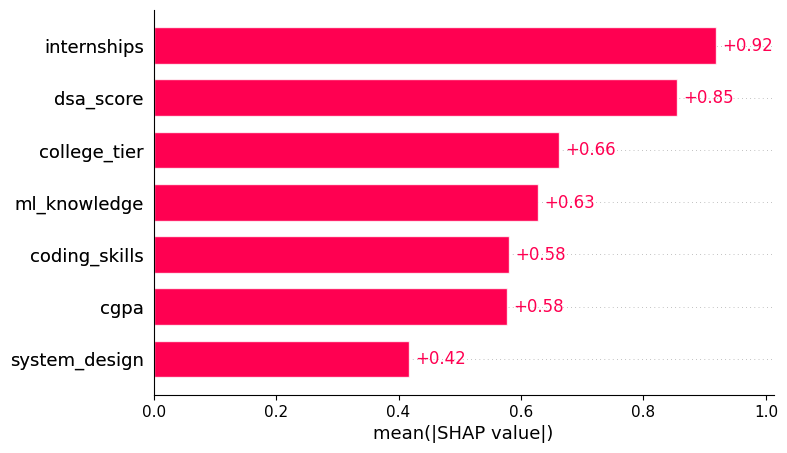

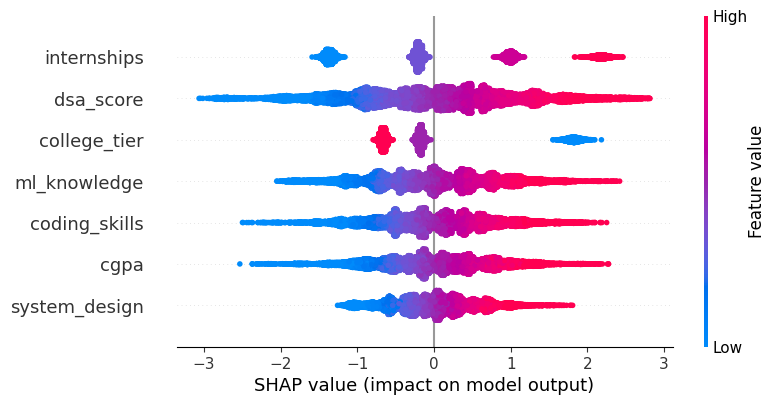

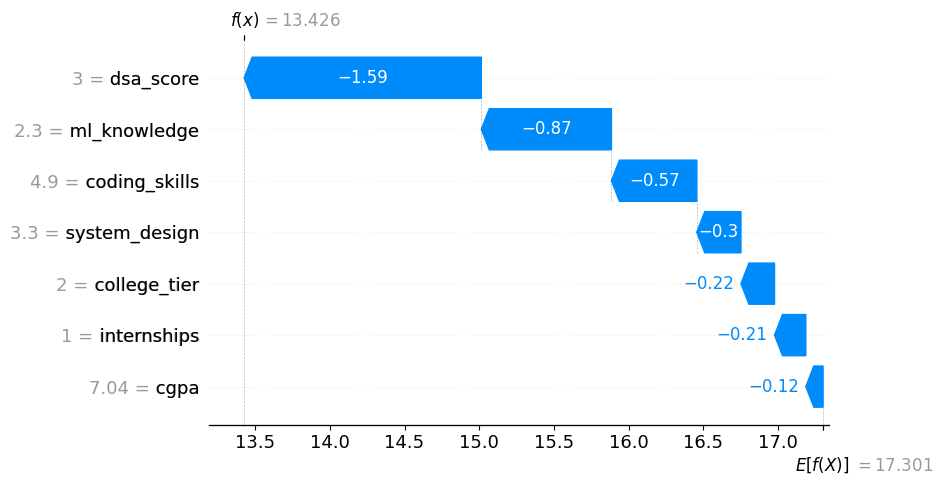

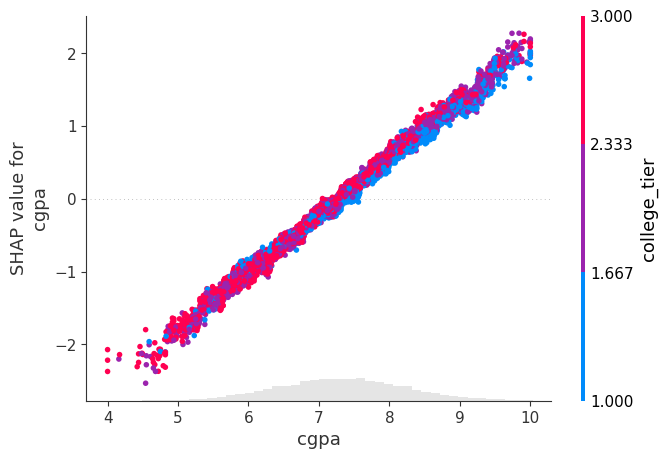

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd


if not isinstance(X_train2, pd.DataFrame):
    X_train2 = pd.DataFrame(X_train2, columns=[
        'internships', 'dsa_score', 'college_tier',
        'ml_knowledge', 'cgpa', 'coding_skills', 'system_design'
    ])

if not isinstance(X_test2, pd.DataFrame):
    X_test2 = pd.DataFrame(X_test2, columns=[
        'internships', 'dsa_score', 'college_tier',
        'ml_knowledge', 'cgpa', 'coding_skills', 'system_design'
    ])


explainer = shap.TreeExplainer(lgbm2)


shap_values = explainer(X_test2)


shap.plots.bar(shap_values, max_display=10)
plt.show()

shap.plots.beeswarm(shap_values, max_display=10)
plt.show()

shap.plots.waterfall(shap_values[0], max_display=10)
plt.show()

shap.plots.scatter(shap_values[:, "cgpa"], color=shap_values)
plt.show()

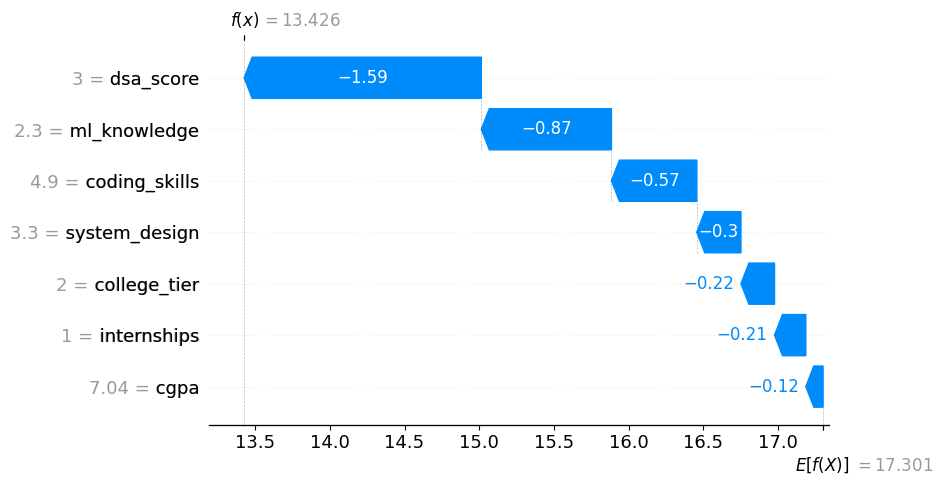

In [ ]:

shap.plots.waterfall(shap_values[0], max_display=10)
plt.show()

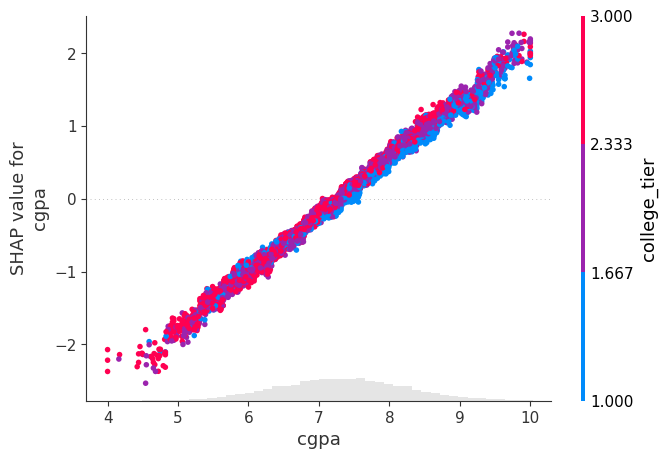

In [ ]:
shap.plots.scatter(shap_values[:, "cgpa"], color=shap_values)
plt.show()